In [3]:
import sys, os
sys.path.append(os.path.abspath(".."))
from src import preprocess

df = preprocess.load_data(r"C:\Users\dutta\housing\data\raw\kc_house_data_NaN.csv")
df = preprocess.clean_data(df)
df = preprocess.engineer_features(df)

X_train, X_test, y_train, y_test = preprocess.split_data(df)

train_temp = X_train.copy()
train_temp['log_price'] = y_train
zipcode_target_map = train_temp.groupby('zipcode')['log_price'].mean()
X_train['zipcode_encoded'] = X_train['zipcode'].map(zipcode_target_map)
X_test['zipcode_encoded'] = X_test['zipcode'].map(zipcode_target_map)

cluster_target_map = train_temp.groupby('location_cluster')['log_price'].mean()
X_train['cluster_avg_price'] = X_train['location_cluster'].map(cluster_target_map)
X_test['cluster_avg_price'] = X_test['location_cluster'].map(cluster_target_map)

X_train = X_train.drop(columns=['zipcode'])
X_test = X_test.drop(columns=['zipcode'])

preprocessor = preprocess.build_preprocessor(X_train)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

c:\Users\dutta\housing\src\preprocess.py:192: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['grade_x_sqft_living'] = df['grade'] * df['sqft_living']
c:\Users\dutta\housing\src\preprocess.py:193: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['age_x_renovated'] = df['house_age'] * df['was_renovated']
c:\Users\dutta\housing\src\preprocess.py:202: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at onc

(17290, 60)
(4323, 60)


In [2]:
import pgeocode
nomi = pgeocode.Nominatim('us')
result = nomi.query_postal_code("98101")
print(result)

postal_code            98101
country_code              US
place_name           Seattle
state_name        Washington
state_code                WA
county_name             King
county_code             33.0
community_name           NaN
community_code           NaN
latitude             47.6114
longitude          -122.3305
accuracy                 4.0
Name: 0, dtype: object


In [1]:
print("test")

test


In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():
    cv_scores = cross_val_score(
        model, X_train_processed, y_train,
        cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    rmse_scores = -cv_scores
    results[name] = {
        'mean_rmse': rmse_scores.mean(),
        'std_rmse': rmse_scores.std()
    }
    print(f"{name}: RMSE = {rmse_scores.mean():.4f} (+/- {rmse_scores.std():.4f})")

Linear Regression: RMSE = 0.1757 (+/- 0.0014)
Random Forest: RMSE = 0.1710 (+/- 0.0021)
XGBoost: RMSE = 0.1663 (+/- 0.0033)


In [5]:
# Approximate dollar-scale RMSE for each model, for intuition
for name, res in results.items():
    approx_dollar_error = np.expm1(res['mean_rmse']) * np.expm1(y_train.mean())
    print(f"{name}: ~RMSE in log scale = {res['mean_rmse']:.4f}")

Linear Regression: ~RMSE in log scale = 0.1757
Random Forest: ~RMSE in log scale = 0.1710
XGBoost: ~RMSE in log scale = 0.1663


In [6]:
from sklearn.metrics import mean_absolute_error

for name, model in models.items():
    model.fit(X_train_processed, y_train)
    preds_log = model.predict(X_test_processed)
    preds_dollar = np.expm1(preds_log)
    actual_dollar = np.expm1(y_test)
    mae_dollar = mean_absolute_error(actual_dollar, preds_dollar)
    print(f"{name}: Test MAE in real dollars = ${mae_dollar:,.0f}")

Linear Regression: Test MAE in real dollars = $75,884
Random Forest: Test MAE in real dollars = $68,481
XGBoost: Test MAE in real dollars = $66,631


In [7]:
xgb_model = models['XGBoost']  # already fit from the previous cell
preds_log = xgb_model.predict(X_test_processed)

preds_dollar = np.expm1(preds_log)
actual_dollar = np.expm1(y_test)

residuals = actual_dollar - preds_dollar

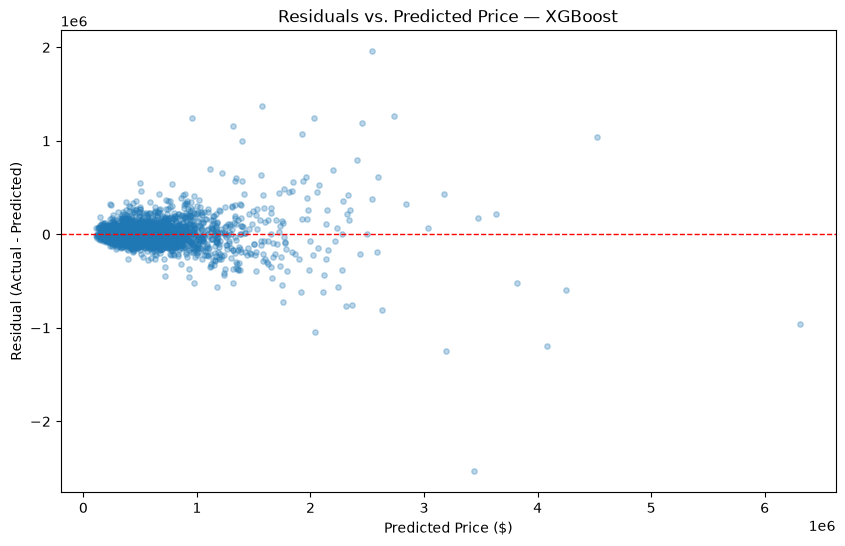

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(preds_dollar, residuals, alpha=0.3, s=15)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.xlabel("Predicted Price ($)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs. Predicted Price — XGBoost")
plt.savefig("../reports/figures/residuals_vs_predicted.png", dpi=150, bbox_inches='tight')
plt.show()

In [9]:
plt.figure(figsize=(10,5))
sns.histplot(residuals, bins=60, kde=True)
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Distribution of Residuals — XGBoost")
plt.xlabel("Residual ($)")
plt.savefig("../reports/figures/residuals_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'sns' is not defined

<Figure size 1000x500 with 0 Axes>

In [10]:
import seaborn as sns


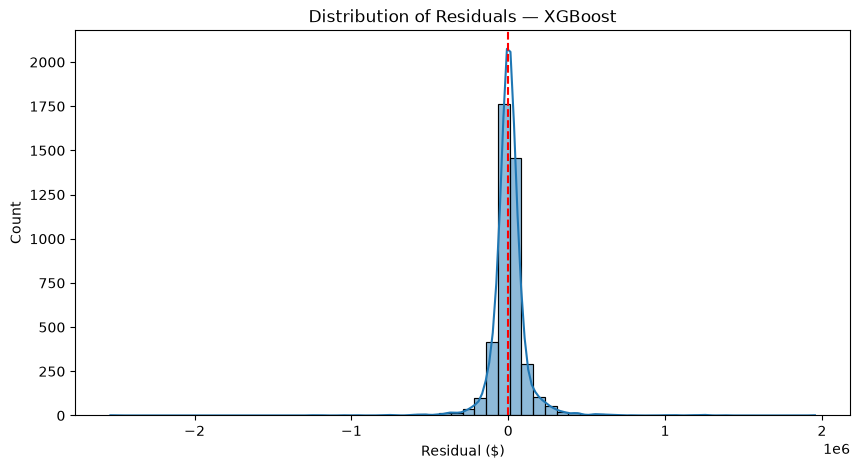

In [11]:
plt.figure(figsize=(10,5))
sns.histplot(residuals, bins=60, kde=True)
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Distribution of Residuals — XGBoost")
plt.xlabel("Residual ($)")
plt.savefig("../reports/figures/residuals_distribution.png", dpi=150, bbox_inches='tight')
plt.show()


In [12]:
error_df = pd.DataFrame({
    'actual': actual_dollar.values,
    'predicted': preds_dollar,
    'residual': residuals.values,
    'abs_error': np.abs(residuals.values)
})

error_df.sort_values('abs_error', ascending=False).head(10)

NameError: name 'pd' is not defined

In [13]:
import pandas as pd
error_df = pd.DataFrame({
    'actual': actual_dollar.values,
    'predicted': preds_dollar,
    'residual': residuals.values,
    'abs_error': np.abs(residuals.values)
})

error_df.sort_values('abs_error', ascending=False).head(10)

,actual,predicted,residual,abs_error
1327,900000.0,3.436332e+06,-2.536332e+06,2.536332e+06
4177,4500000.0,2.544640e+06,1.955360e+06,1.955360e+06
1184,2950000.0,1.573687e+06,1.376313e+06,1.376313e+06
3195,4000000.0,2.731910e+06,1.268090e+06,1.268090e+06
3193,1940000.0,3.190988e+06,-1.250988e+06,1.250988e+06
1283,2205000.0,9.594656e+05,1.245534e+06,1.245534e+06
3719,3278000.0,2.033979e+06,1.244021e+06,1.244021e+06
4217,2888000.0,4.084973e+06,-1.196973e+06,1.196973e+06
1992,3650000.0,2.455451e+06,1.194549e+06,1.194549e+06
1563,2475000.0,1.315977e+06,1.159023e+06,1.159023e+06


In [14]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

param_distributions = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb_base = XGBRegressor(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=30,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_processed, y_train)

print("Best parameters:", random_search.best_params_)
print("Best CV RMSE:", -random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best CV RMSE: 0.15833672514760802


In [15]:
best_xgb = random_search.best_estimator_

test_preds_log = best_xgb.predict(X_test_processed)
test_preds_dollar = np.expm1(test_preds_log)
actual_dollar_test = np.expm1(y_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

final_rmse = np.sqrt(mean_squared_error(y_test, test_preds_log))
final_mae_dollar = mean_absolute_error(actual_dollar_test, test_preds_dollar)
final_r2 = r2_score(y_test, test_preds_log)

print(f"Final Tuned XGBoost — Test RMSE (log scale): {final_rmse:.4f}")
print(f"Final Tuned XGBoost — Test MAE (real dollars): ${final_mae_dollar:,.0f}")
print(f"Final Tuned XGBoost — Test R²: {final_r2:.4f}")

Final Tuned XGBoost — Test RMSE (log scale): 0.1558
Final Tuned XGBoost — Test MAE (real dollars): $62,141
Final Tuned XGBoost — Test R²: 0.9148


In [16]:
import pandas as pd

# Get feature names after the ColumnTransformer (numeric + binary + one-hot cluster columns)
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)

importance_df.head(20)

,feature,importance
37,num__zipcode_encoded,0.296342
44,bin__is_luxury,0.183021
30,num__grade_x_sqft_living,0.115515
26,num__luxury_score,0.096544
38,num__cluster_avg_price,0.047163
35,num__sqft_living_log,0.040767
8,num__lat,0.024095
39,bin__waterfront,0.018772
27,num__amenity_proximity_pc1,0.014630
5,num__grade,0.011318


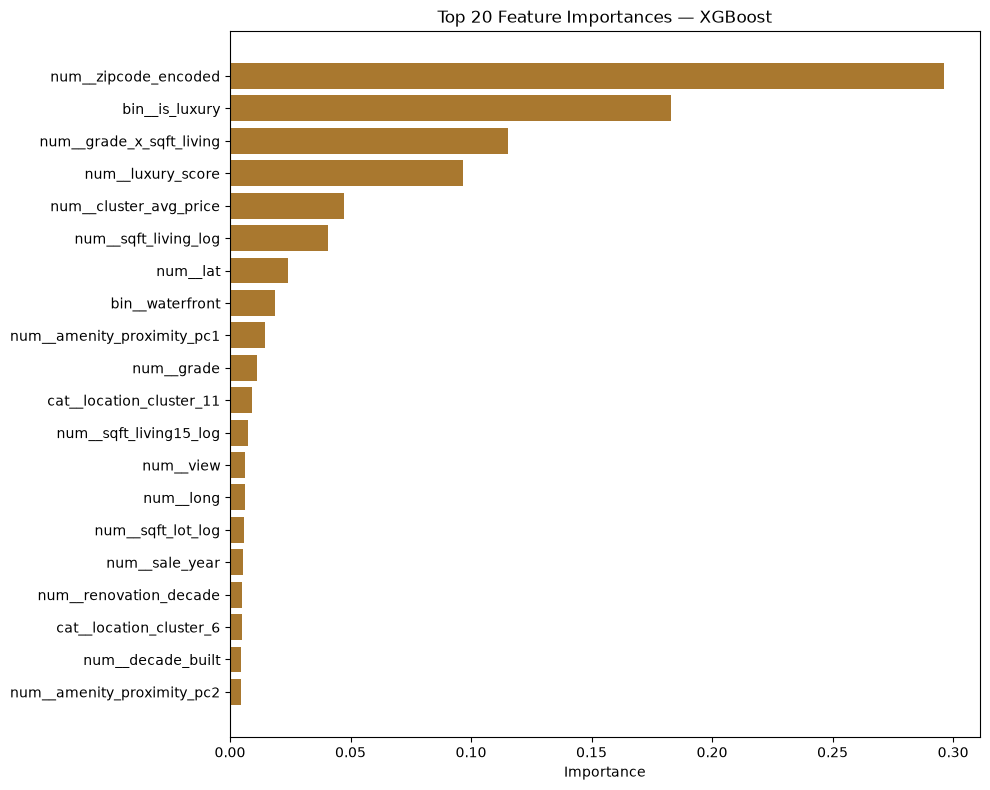

In [17]:
plt.figure(figsize=(10,8))
top20 = importance_df.head(20)
plt.barh(top20['feature'][::-1], top20['importance'][::-1], color='#A9782F')
plt.title("Top 20 Feature Importances — XGBoost")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("../reports/figures/feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

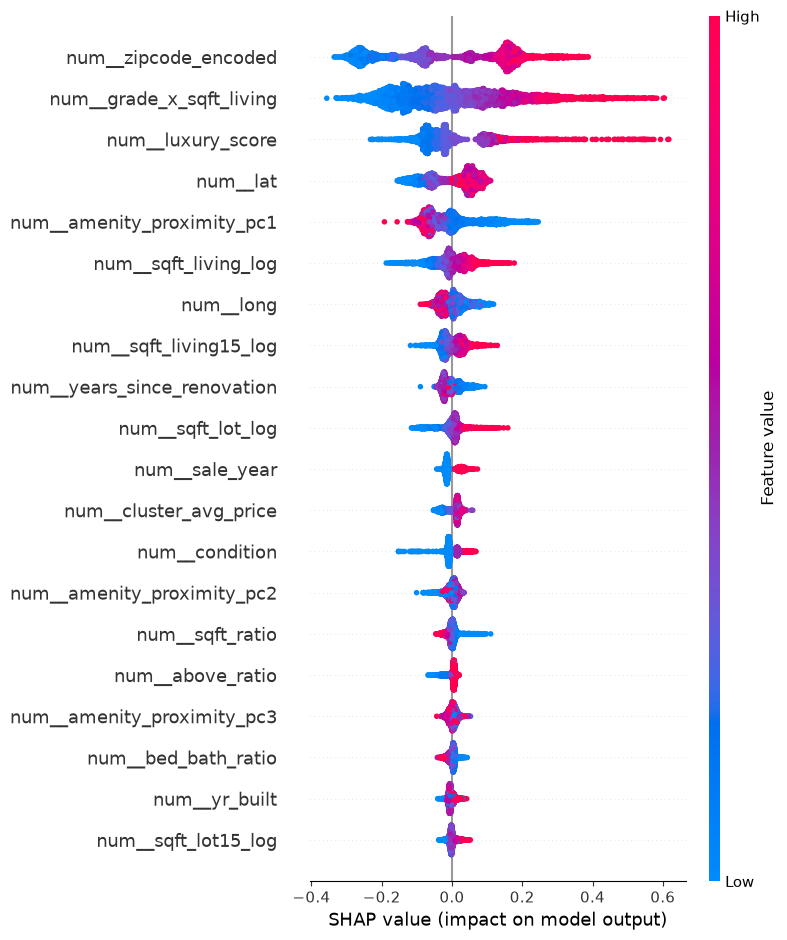

In [18]:
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_processed)

shap.summary_plot(shap_values, X_test_processed, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig("../reports/figures/shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()

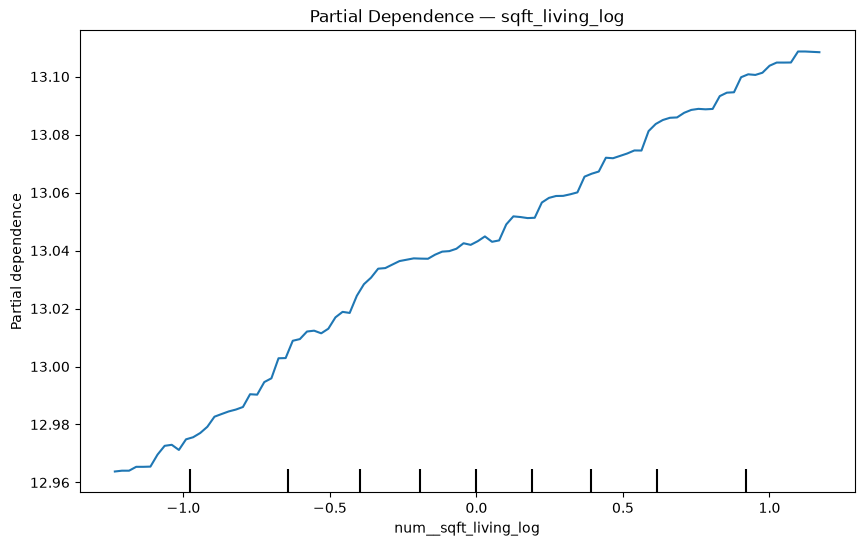

In [19]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(
    best_xgb, X_train_processed, 
    features=[list(feature_names).index('num__sqft_living_log')],
    feature_names=feature_names, ax=ax
)
plt.title("Partial Dependence — sqft_living_log")
plt.savefig("../reports/figures/pdp_sqft_living.png", dpi=150, bbox_inches='tight')
plt.show()

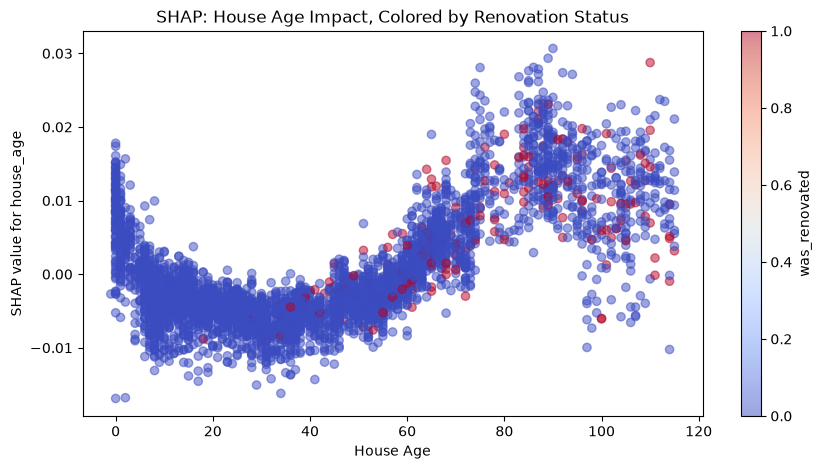

In [22]:
renovation_idx = list(feature_names).index('num__yr_renovated')
age_idx = list(feature_names).index('num__house_age')

plt.figure(figsize=(10,5))
plt.scatter(X_test['house_age'], shap_values[:, age_idx], 
            c=X_test['was_renovated'], cmap='coolwarm', alpha=0.5)
plt.colorbar(label='was_renovated')
plt.xlabel("House Age")
plt.ylabel("SHAP value for house_age")
plt.title("SHAP: House Age Impact, Colored by Renovation Status")
plt.savefig("../reports/figures/shap_age_renovation_check.png", dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Quick check: see how binary columns are actually named after transformation
[f for f in feature_names if 'renovat' in f.lower() or 'age' in f.lower()]

['num__yr_renovated',
 'num__house_age',
 'num__years_since_renovation',
 'num__renovation_decade',
 'num__age_x_renovated',
 'bin__was_renovated']

In [24]:
baseline_prediction = np.full_like(y_test, fill_value=y_train.mean())

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_prediction))
baseline_mae = mean_absolute_error(y_test, baseline_prediction)
baseline_r2 = r2_score(y_test, baseline_prediction)

baseline_dollar_prediction = np.expm1(baseline_prediction)
actual_dollar = np.expm1(y_test)
baseline_dollar_mae = mean_absolute_error(actual_dollar, baseline_dollar_prediction)

print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Baseline dollar MAE: ${baseline_dollar_mae:,.0f}")

Baseline RMSE: 0.5340
Baseline dollar MAE: $229,795


In [25]:
import sys, os
sys.path.append(os.path.abspath(".."))
from src import preprocess, train

# Full data pipeline (Stage 2-7)
df = preprocess.load_data(r"C:\Users\dutta\housing\data\raw\kc_house_data_NaN.csv")
df = preprocess.clean_data(df)
df = preprocess.engineer_features(df)
X_train, X_test, y_train, y_test = preprocess.split_data(df)

train_temp = X_train.copy()
train_temp['log_price'] = y_train
zipcode_target_map = train_temp.groupby('zipcode')['log_price'].mean()
X_train['zipcode_encoded'] = X_train['zipcode'].map(zipcode_target_map)
X_test['zipcode_encoded'] = X_test['zipcode'].map(zipcode_target_map)

cluster_target_map = train_temp.groupby('location_cluster')['log_price'].mean()
X_train['cluster_avg_price'] = X_train['location_cluster'].map(cluster_target_map)
X_test['cluster_avg_price'] = X_test['location_cluster'].map(cluster_target_map)

X_train = X_train.drop(columns=['zipcode'])
X_test = X_test.drop(columns=['zipcode'])

preprocessor = preprocess.build_preprocessor(X_train)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Modeling pipeline (Stage 8-11) — this is the new part
baseline_results = train.train_baseline(y_train, y_test)
models, comparison_df = train.compare_models(X_train_processed, y_train, X_test_processed, y_test)
random_search = train.tune_xgboost(X_train_processed, y_train)

best_xgb = random_search.best_estimator_
final_preds = best_xgb.predict(X_test_processed)
final_results = train.evaluate_predictions(y_test, final_preds, label="XGBoost (tuned)")

c:\Users\dutta\housing\src\preprocess.py:192: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['grade_x_sqft_living'] = df['grade'] * df['sqft_living']
c:\Users\dutta\housing\src\preprocess.py:193: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['age_x_renovated'] = df['house_age'] * df['was_renovated']
c:\Users\dutta\housing\src\preprocess.py:202: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at onc

Baseline (mean) — RMSE(log): 0.5340 | R²: -0.0006 | MAE: $229,795
Linear Regression — RMSE(log): 0.1781 | R²: 0.8887 | MAE: $75,884
Random Forest — RMSE(log): 0.1689 | R²: 0.8999 | MAE: $68,481
XGBoost — RMSE(log): 0.1638 | R²: 0.9058 | MAE: $66,631
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best CV RMSE: 0.15833672514760802
XGBoost (tuned) — RMSE(log): 0.1558 | R²: 0.9148 | MAE: $62,141


In [26]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("king_county_house_price")

# Baseline
with mlflow.start_run(run_name="baseline_mean"):
    mlflow.log_param("model_type", "baseline_mean")
    mlflow.log_metric("rmse_log", baseline_results['rmse_log'])
    mlflow.log_metric("r2", baseline_results['r2'])
    mlflow.log_metric("mae_dollar", baseline_results['mae_dollar'])

# The three compared models
for _, row in comparison_df.iterrows():
    with mlflow.start_run(run_name=row['label'].replace(" ", "_")):
        mlflow.log_param("model_type", row['label'])
        mlflow.log_metric("rmse_log", row['rmse_log'])
        mlflow.log_metric("r2", row['r2'])
        mlflow.log_metric("mae_dollar", row['mae_dollar'])

# Final tuned XGBoost — with hyperparameters and the model itself
with mlflow.start_run(run_name="xgboost_tuned"):
    mlflow.log_params(random_search.best_params_)
    mlflow.log_metric("rmse_log", final_results['rmse_log'])
    mlflow.log_metric("r2", final_results['r2'])
    mlflow.log_metric("mae_dollar", final_results['mae_dollar'])
    mlflow.sklearn.log_model(best_xgb, "model")

print("All runs logged to MLflow.")

2026/09/19 07:19:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MlflowException: The saved sklearn model references untrusted types. If you are sure loading these types is safe, set the 'skops_trusted_types' parameter when calling 'log_model' or 'save_model' to the list of trusted types. Root error: Untrusted types found in the file: ['xgboost.core.Booster', 'xgboost.sklearn.XGBRegressor'].

In [27]:
import mlflow.xgboost

with mlflow.start_run(run_name="xgboost_tuned"):
    mlflow.log_params(random_search.best_params_)
    mlflow.log_metric("rmse_log", final_results['rmse_log'])
    mlflow.log_metric("r2", final_results['r2'])
    mlflow.log_metric("mae_dollar", final_results['mae_dollar'])
    mlflow.xgboost.log_model(best_xgb, "model")

print("Tuned XGBoost run logged successfully.")

2026/09/19 07:22:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Tuned XGBoost run logged successfully.


In [28]:
import os
print(os.getcwd())

c:\Users\dutta\housing\notebooks


In [30]:
import mlflow
import mlflow.xgboost

# Explicitly set tracking location — no ambiguity about working directory
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("king_county_house_price")

print("Tracking URI:", mlflow.get_tracking_uri())

# Baseline
with mlflow.start_run(run_name="baseline_mean"):
    mlflow.log_param("model_type", "baseline_mean")
    mlflow.log_metric("rmse_log", baseline_results['rmse_log'])
    mlflow.log_metric("r2", baseline_results['r2'])
    mlflow.log_metric("mae_dollar", baseline_results['mae_dollar'])

# Compared models
for _, row in comparison_df.iterrows():
    with mlflow.start_run(run_name=row['label'].replace(" ", "_")):
        mlflow.log_param("model_type", row['label'])
        mlflow.log_metric("rmse_log", row['rmse_log'])
        mlflow.log_metric("r2", row['r2'])
        mlflow.log_metric("mae_dollar", row['mae_dollar'])

# Final tuned XGBoost
with mlflow.start_run(run_name="xgboost_tuned"):
    mlflow.log_params(random_search.best_params_)
    mlflow.log_metric("rmse_log", final_results['rmse_log'])
    mlflow.log_metric("r2", final_results['r2'])
    mlflow.log_metric("mae_dollar", final_results['mae_dollar'])
    mlflow.xgboost.log_model(best_xgb, name="model")

print("All 5 runs logged successfully.")

MlflowException: The filesystem tracking backend (e.g., './mlruns') is in maintenance mode and will not receive further updates. Please migrate to a database backend (e.g., 'sqlite:///mlflow.db') to access the latest MLflow features. The `mlflow migrate-filestore` tool migrates your existing data losslessly. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance. If the filesystem backend is required for your workflow, set `MLFLOW_ALLOW_FILE_STORE=true` to opt out of this exception.

In [31]:
import mlflow
import mlflow.xgboost

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("king_county_house_price")

print("Tracking URI:", mlflow.get_tracking_uri())

with mlflow.start_run(run_name="baseline_mean"):
    mlflow.log_param("model_type", "baseline_mean")
    mlflow.log_metric("rmse_log", baseline_results['rmse_log'])
    mlflow.log_metric("r2", baseline_results['r2'])
    mlflow.log_metric("mae_dollar", baseline_results['mae_dollar'])

for _, row in comparison_df.iterrows():
    with mlflow.start_run(run_name=row['label'].replace(" ", "_")):
        mlflow.log_param("model_type", row['label'])
        mlflow.log_metric("rmse_log", row['rmse_log'])
        mlflow.log_metric("r2", row['r2'])
        mlflow.log_metric("mae_dollar", row['mae_dollar'])

with mlflow.start_run(run_name="xgboost_tuned"):
    mlflow.log_params(random_search.best_params_)
    mlflow.log_metric("rmse_log", final_results['rmse_log'])
    mlflow.log_metric("r2", final_results['r2'])
    mlflow.log_metric("mae_dollar", final_results['mae_dollar'])
    mlflow.xgboost.log_model(best_xgb, name="model")

print("All 5 runs logged successfully.")

Tracking URI: sqlite:///mlflow.db
All 5 runs logged successfully.


In [32]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(preprocessor, "../models/preprocessor.pkl")
joblib.dump(best_xgb, "../models/xgb_model.pkl")

print("Preprocessor and model saved to /models")

Preprocessor and model saved to /models


In [33]:
loaded_preprocessor = joblib.load("../models/preprocessor.pkl")
loaded_model = joblib.load("../models/xgb_model.pkl")

X_test_reloaded = loaded_preprocessor.transform(X_test)
reloaded_preds = loaded_model.predict(X_test_reloaded)

original_preds = best_xgb.predict(X_test_processed)
print("Predictions match exactly:", np.allclose(reloaded_preds, original_preds))

Predictions match exactly: True


In [34]:
import json

metadata = {
    "model_type": "XGBoost (tuned)",
    "best_params": random_search.best_params_,
    "test_rmse_log": final_results['rmse_log'],
    "test_r2": final_results['r2'],
    "test_mae_dollar": final_results['mae_dollar'],
    "feature_count": X_train_processed.shape[1],
    "training_rows": X_train_processed.shape[0]
}

with open("../models/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Metadata saved.")

Metadata saved.


In [35]:
df['log_price'] = np.log1p(df['price'])

In [36]:
kmeans_model = preprocess.fit_location_clusters(df)
joblib.dump(kmeans_model, "../models/kmeans_model.pkl")

AttributeError: module 'src.preprocess' has no attribute 'fit_location_clusters'

In [37]:
df, kmeans_model, pca_model, pca_scaler = preprocess.engineer_features(df)

ValueError: too many values to unpack (expected 4)

In [38]:
import inspect
print(inspect.getsource(preprocess.engineer_features))

def apply_log_transforms(df):
    """Stage 5: log-transform skewed sqft columns."""
    skewed_cols = ['sqft_lot', 'sqft_lot15', 'sqft_basement',
                   'sqft_living', 'sqft_above', 'sqft_living15']
    for col in skewed_cols:
        df[f'{col}_log'] = np.log1p(df[col])
    return df



In [39]:
import inspect
print(inspect.getsource(preprocess.engineer_features))

def apply_log_transforms(df):
    """Stage 5: log-transform skewed sqft columns."""
    skewed_cols = ['sqft_lot', 'sqft_lot15', 'sqft_basement',
                   'sqft_living', 'sqft_above', 'sqft_living15']
    for col in skewed_cols:
        df[f'{col}_log'] = np.log1p(df[col])
    return df



In [41]:
import inspect
source_code = inspect.getsource(preprocess.engineer_features)
print(source_code)

def apply_log_transforms(df):
    """Stage 5: log-transform skewed sqft columns."""
    skewed_cols = ['sqft_lot', 'sqft_lot15', 'sqft_basement',
                   'sqft_living', 'sqft_above', 'sqft_living15']
    for col in skewed_cols:
        df[f'{col}_log'] = np.log1p(df[col])
    return df



In [42]:
result = preprocess.engineer_features(df)
print(type(result))
print(len(result) if isinstance(result, tuple) else "not a tuple")

<class 'pandas.DataFrame'>
not a tuple


In [1]:
df, kmeans_model, pca_model, pca_scaler = preprocess.engineer_features(df)

NameError: name 'preprocess' is not defined

In [2]:
import sys, os
sys.path.append(os.path.abspath(".."))
from src import preprocess

In [3]:
df = preprocess.load_data(r"C:\Users\dutta\housing\data\raw\kc_house_data_NaN.csv")
df = preprocess.clean_data(df)

In [4]:
df, kmeans_model, pca_model, pca_scaler = preprocess.engineer_features(df)

RUNNING NEW VERSION


c:\Users\dutta\housing\src\preprocess.py:211: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['grade_x_sqft_living'] = df['grade'] * df['sqft_living']
c:\Users\dutta\housing\src\preprocess.py:212: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['age_x_renovated'] = df['house_age'] * df['was_renovated']
c:\Users\dutta\housing\src\preprocess.py:221: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at onc

In [5]:
X_train, X_test, y_train, y_test = preprocess.split_data(df)

train_temp = X_train.copy()
train_temp['log_price'] = y_train
zipcode_target_map = train_temp.groupby('zipcode')['log_price'].mean()
X_train['zipcode_encoded'] = X_train['zipcode'].map(zipcode_target_map)
X_test['zipcode_encoded'] = X_test['zipcode'].map(zipcode_target_map)

cluster_target_map = train_temp.groupby('location_cluster')['log_price'].mean()
X_train['cluster_avg_price'] = X_train['location_cluster'].map(cluster_target_map)
X_test['cluster_avg_price'] = X_test['location_cluster'].map(cluster_target_map)

X_train = X_train.drop(columns=['zipcode'])
X_test = X_test.drop(columns=['zipcode'])

preprocessor = preprocess.build_preprocessor(X_train)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(17290, 60)
(4323, 60)


In [6]:
from src import train
import joblib

baseline_results = train.train_baseline(y_train, y_test)
models, comparison_df = train.compare_models(X_train_processed, y_train, X_test_processed, y_test)
random_search = train.tune_xgboost(X_train_processed, y_train)

best_xgb = random_search.best_estimator_
final_preds = best_xgb.predict(X_test_processed)
final_results = train.evaluate_predictions(y_test, final_preds, label="XGBoost (tuned)")

joblib.dump(preprocessor, "../models/preprocessor.pkl")
joblib.dump(best_xgb, "../models/xgb_model.pkl")
joblib.dump(kmeans_model, "../models/kmeans_model.pkl")
joblib.dump(pca_model, "../models/pca_model.pkl")
joblib.dump(pca_scaler, "../models/pca_scaler.pkl")

print("All models re-saved.")

Baseline (mean) — RMSE(log): 0.5340 | R²: -0.0006 | MAE: $229,795
Linear Regression — RMSE(log): 0.1781 | R²: 0.8887 | MAE: $75,884
Random Forest — RMSE(log): 0.1689 | R²: 0.8999 | MAE: $68,481
XGBoost — RMSE(log): 0.1638 | R²: 0.9058 | MAE: $66,631
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best CV RMSE: 0.15833672514760802
XGBoost (tuned) — RMSE(log): 0.1558 | R²: 0.9148 | MAE: $62,141
All models re-saved.
